In [1]:
from reflect.components.flow_world_model.dynamic_model import DynamicFlowModel
from reflect.components.flow_world_model.world_model_actor import WorldModelActor
from reflect.components.flow_world_model.world_model import WorldModel
from reflect.data.loader import EnvDataLoader
from reflect.components.models.actor import Actor

from tqdm import tqdm
from livelossplot import PlotLosses
import gymnasium as gym
from dataclasses import asdict
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim

/Users/alexathorne/development/personal/world-model-rl/venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_moons


class TwoMoonsDataset(Dataset):
    def __init__(self, n_samples=1000, noise=0.1):
        X, y = make_moons(n_samples=n_samples, noise=noise)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# create dataset
dataset = TwoMoonsDataset(n_samples=10_000, noise=0.1)

# create dataloader
dataloader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True,
    drop_last=False
)

# example usage
for x, y in dataloader:
    print(x.shape, y.shape)
    break


torch.Size([256, 2]) torch.Size([256])


In [11]:
state_dim = 2

dynamic_model = DynamicFlowModel(
    input_dim=state_dim,
    conditioning_dim=0,
    output_dim=state_dim,
    time_embed_dim=16,
    hidden_dim=128,
    depth=2,
    use_layer_norm=True,
)

In [12]:
from reflect.utils import (
    AdamOptim,
)

optimizer = optim.Adam(dynamic_model.parameters(), lr=1e-3)

In [13]:
time_coeff = 0

In [14]:
def _update(
        x: torch.Tensor,
        flow_model: DynamicFlowModel,
        t_pred_ratio: float = 0,
    ):
    optimizer.zero_grad()
    b, d = x.shape
    t = torch.rand(b, 1, device=x.device)
    x_sample = torch.randn_like(x)
    x_interp = (1 - t) * x_sample + t * x
    v = x - x_sample    
    x_cond = torch.empty(x.shape[0], 0, device=x.device)
    u = dynamic_model.forward(x_cond, x_interp, t)
    u_loss = ((u - v) ** 2).mean()
    loss = u_loss
    loss.backward()
    optimizer.step()

    rel_err = (
        (u - v).norm(dim=1)
        / (v.norm(dim=1) + 1e-4)
    ).mean()
    return {
        'flow_loss': u_loss.item(),
        'rel_err': rel_err.item()
    }

In [15]:
plot_losses = PlotLosses(
  groups={
    'flow_loss': ['flow_loss'],
  },
)

In [16]:
for epoch in range(100):
    total_loss = 0.0
    total_rel_err = 0.0
    for batch, _ in dataloader:
        batch = batch.view(batch.shape[0], -1)
        losses = _update(batch, dynamic_model, 0)
        total_loss += losses['flow_loss']
        total_rel_err += losses['rel_err']
    print(f"Epoch {epoch:03d} | loss = {total_loss / len(dataloader):.4f} | rel_err = {total_rel_err / len(dataloader):.4f}")


Epoch 000 | loss = 1.3136 | rel_err = 1.0379
Epoch 001 | loss = 1.1683 | rel_err = 1.0104
Epoch 002 | loss = 1.1180 | rel_err = 1.0123
Epoch 003 | loss = 1.1135 | rel_err = 0.9980
Epoch 004 | loss = 1.0714 | rel_err = 1.0089
Epoch 005 | loss = 1.0849 | rel_err = 1.0190
Epoch 006 | loss = 1.0584 | rel_err = 1.0138
Epoch 007 | loss = 1.0584 | rel_err = 1.0247
Epoch 008 | loss = 1.0493 | rel_err = 0.9796
Epoch 009 | loss = 1.0502 | rel_err = 1.0309
Epoch 010 | loss = 1.0201 | rel_err = 0.9833
Epoch 011 | loss = 1.0475 | rel_err = 1.0033
Epoch 012 | loss = 1.0503 | rel_err = 1.0011
Epoch 013 | loss = 1.0614 | rel_err = 0.9921
Epoch 014 | loss = 1.0487 | rel_err = 0.9977
Epoch 015 | loss = 1.0203 | rel_err = 0.9896
Epoch 016 | loss = 1.0269 | rel_err = 1.0014
Epoch 017 | loss = 1.0491 | rel_err = 0.9837
Epoch 018 | loss = 1.0378 | rel_err = 1.0080
Epoch 019 | loss = 1.0285 | rel_err = 0.9916
Epoch 020 | loss = 1.0255 | rel_err = 1.0009
Epoch 021 | loss = 1.0045 | rel_err = 0.9899
Epoch 022 

In [9]:
import matplotlib.pyplot as plt

In [17]:
def plot_vector_field(t):
    # square bounds around `data
    padding = 0.5
    grid_size = 50
    device='cpu'
    X = dataloader.dataset.X
    mins, _ = X.min(dim=0)
    maxs, _ = X.max(dim=0)
    center = (mins + maxs) / 2
    half_side = torch.max((maxs - mins) / 2).item() + padding

    x_min, x_max = (center[0].item() - half_side), (center[0].item() + half_side)
    y_min, y_max = (center[1].item() - half_side), (center[1].item() + half_side)

    # mesh
    xs = torch.linspace(x_min, x_max, grid_size, device=device)
    ys = torch.linspace(y_min, y_max, grid_size, device=device)
    xx, yy = torch.meshgrid(xs, ys, indexing="xy")              # (G,G)
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1) # (G*G,2)

    # time broadcast (common convention: (B,) )
    tt = torch.full((grid.shape[0],), float(t), device=device)
    a = torch.empty(grid.shape[0], 0, device=device)

    # eval
    dynamic_model.eval()
    with torch.no_grad():
        v = dynamic_model(a, grid, tt)  # expected (G*G,2)

    v = v.reshape(grid_size, grid_size, 2)

    xx, yy, v = xx.detach().cpu(), yy.detach().cpu(), v.detach().cpu()
    fig, ax = plt.subplots(figsize=(12, 12))

    u = v[..., 0]
    w = v[..., 1]

    ax.quiver(
        xx.numpy(),
        yy.numpy(),
        u.numpy(),
        w.numpy(),
        angles="xy",
        scale_units="xy",
        scale=10,
    )

    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(alpha=0.3)

    ax.scatter(X[:, 0], X[:, 1], s=10, c="black", alpha=0.5)

    plt.show()

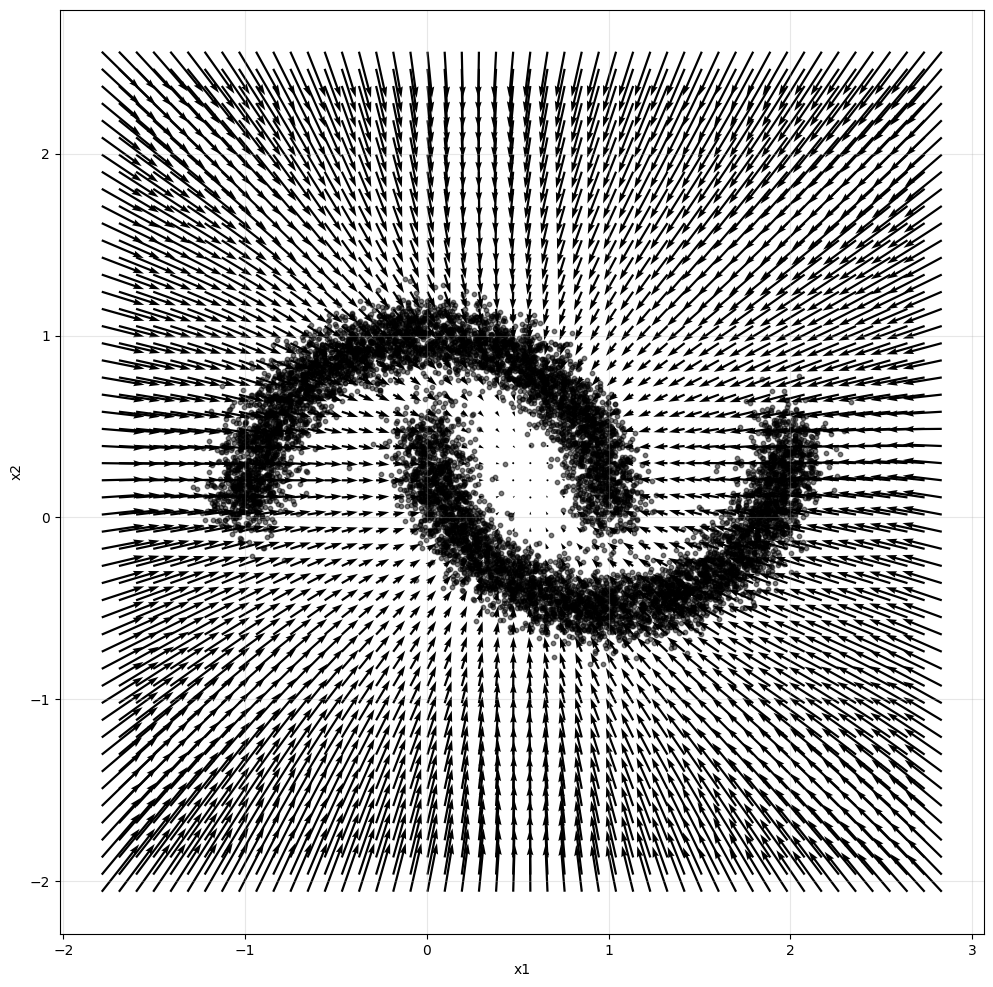

In [18]:
plot_vector_field(0)

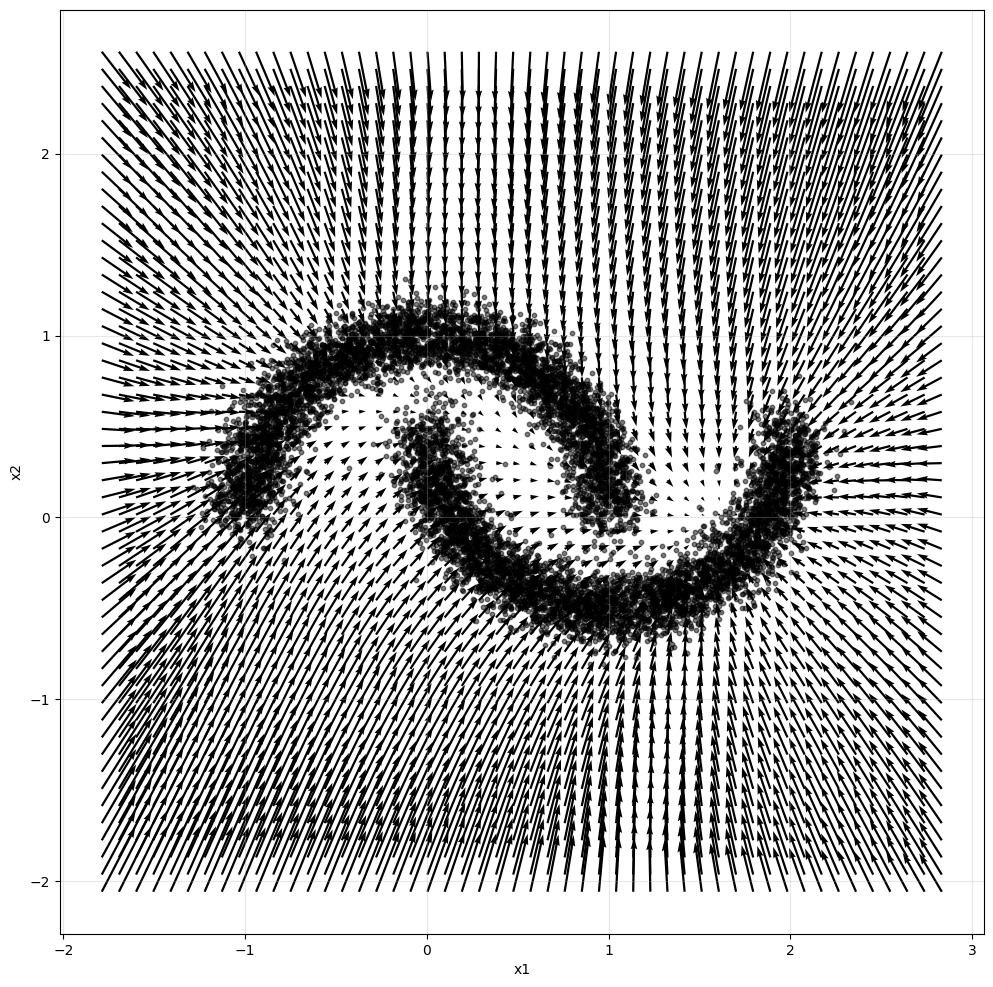

In [19]:
plot_vector_field(0.5)

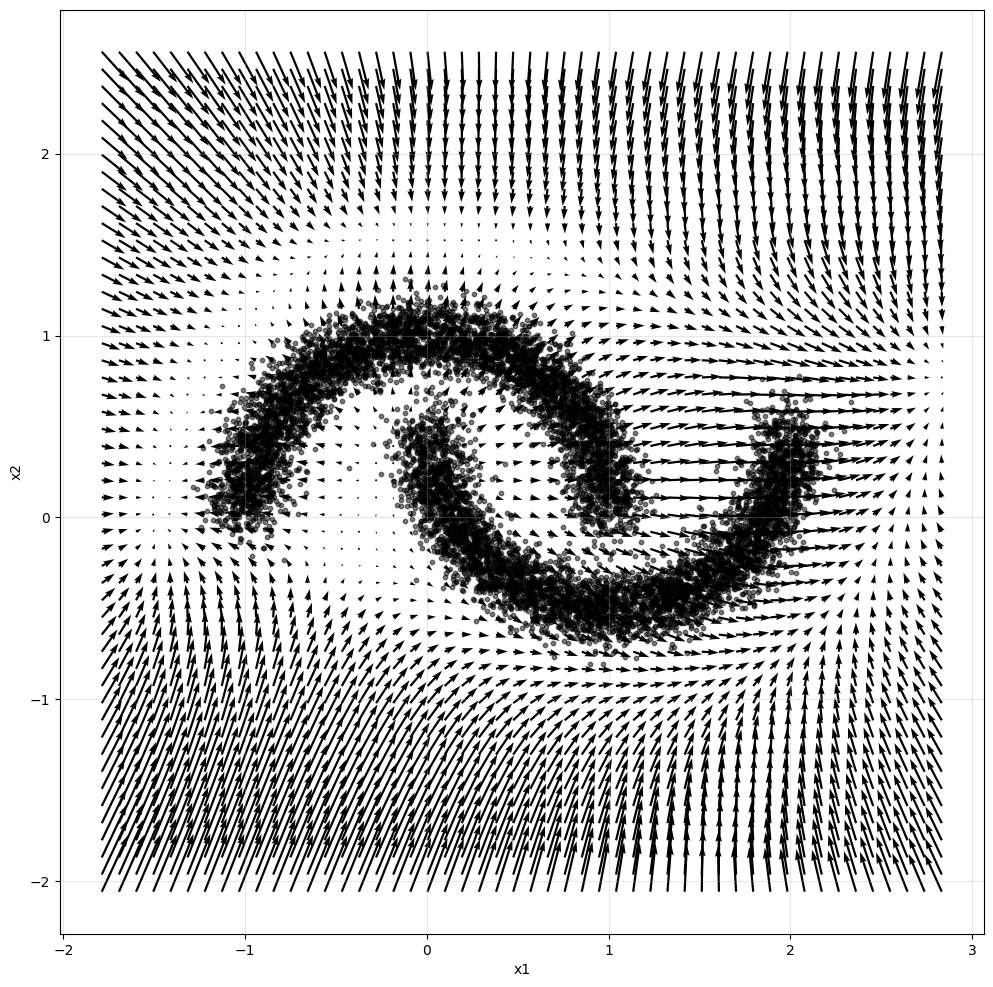

In [20]:
plot_vector_field(1.)

In [21]:
def _step(
        flow_model: DynamicFlowModel,
        x: torch.Tensor,
        t: torch.Tensor,
        delta: float,
        step_type: str = 'euler',
    ):    
    a = torch.empty(1, 0, device=x.device)
    if step_type == 'euler':
        u = flow_model.forward(a, x, t)
        x_next = x + u * delta
        return x_next, t + delta
    else:
        raise ValueError(f'Invalid step type: {step_type}')

In [22]:
def get_trajectory(num_steps=100):
    i = torch.randn(1, 2)
    t = torch.tensor(0.0)
    delta = 1/num_steps
    step_type = 'euler'
    trajectory = []
    for _ in range(num_steps):
        i, t = _step(dynamic_model, i, t, delta, step_type)
        trajectory.append(i)
        i = i.view(1, 2)

    trajectory = torch.cat(trajectory)[:, :].detach()
    return trajectory

100%|██████████| 100/100 [00:05<00:00, 17.80it/s]


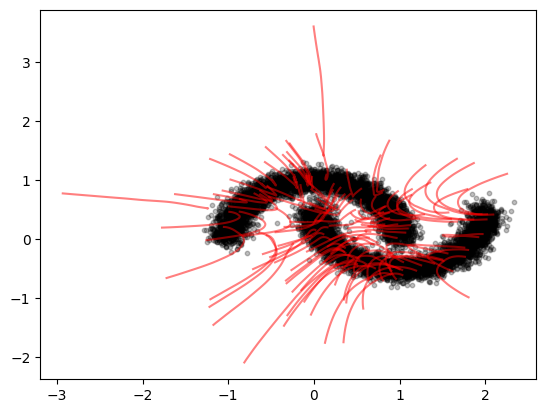

In [23]:
fig, ax = plt.subplots()
ax.scatter(dataloader.dataset.X[:, 0], dataloader.dataset.X[:, 1], s=10, c="black", alpha=0.25)
for _ in tqdm(range(100)):
    trajectory = get_trajectory()
    ax.plot(trajectory[:, 0], trajectory[:, 1], c="red", alpha=0.5)
plt.show()



In [24]:
dps = []
for _ in tqdm(range(1000)):
    trajectory = get_trajectory()
    dps.append([trajectory[-1, 0], trajectory[-1, 1]])

100%|██████████| 1000/1000 [01:09<00:00, 14.47it/s]


In [25]:
dps_c = torch.cat([torch.tensor(dp).unsqueeze(0) for dp in dps])

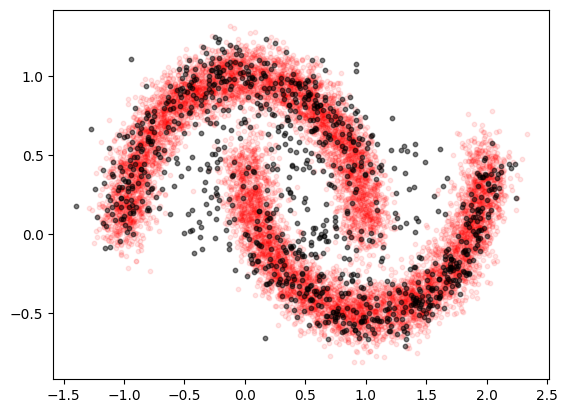

In [26]:
fig, ax = plt.subplots()
ax.scatter(dataloader.dataset.X[:, 0], dataloader.dataset.X[:, 1], s=10, c="red", alpha=0.1)
ax.scatter(dps_c[:, 0], dps_c[:, 1], s=10, c="black", alpha=0.5)
plt.show()
